# Domain-wise Error Comparison of Best Dotting Models

Per-domain Word Error Rate (WER %) comparison for the best variant of each model family on the **test** set. Figure is sized for a **single column** in a two-column paper layout.

**Configurable**: edit the `MODELS` dict below to add/remove any model variant.

In [11]:
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Configuration

All knobs live here. To add a variant, append a `display name -> path` entry to `MODELS`. To remove one, delete its entry. To change domain ordering or labels, edit `DOMAINS_ORDER` / `DOMAIN_LABELS`.

In [12]:
# --- Models -----------------------------------------------------------------
# Add or remove variants freely. Each key is the figure label.
# Paths are relative to the `tnqeet/` package root (the inner one, containing
# `dotting_models/`). PACKAGE_ROOT below is resolved by walking up from CWD,
# so the notebook works whether you run it from the repo root, the package
# root, or the notebooks/ directory.

def _find_package_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        candidate = parent / 'dotting_models'
        if candidate.is_dir():
            return parent
        candidate = parent / 'tnqeet' / 'dotting_models'
        if candidate.is_dir():
            return parent / 'tnqeet'
    raise RuntimeError(
        f"Could not locate the tnqeet package root (looked for a 'dotting_models/' "
        f"directory above {start}). Set PACKAGE_ROOT manually below."
    )

PACKAGE_ROOT = _find_package_root(Path.cwd())

# Keys are the labels printed on the chart; values are the result-file paths.
# Variant suffixes are kept out of the labels — add them back here if you want
# multiple variants of the same family to coexist (e.g. 'LSTM-5', 'LSTM-3').
MODELS = {
    'N-gram':       'dotting_models/ngrams/evaluation_results/test_dataset/beam_size_60/ngrams_8.json',
    'LSTM':         'dotting_models/sequence_labeling/evaluation_results/test_dataset/LSTM_layers_5_results.json',
    'Transformer':  'dotting_models/transformer/evaluation_results/test_dataset/Transformer_layers_12_results.json',
    'CANINE-S':     'dotting_models/canine/evaluation_results/test_dataset/CANINE-canine-s_results.json',
    'Claude':       'dotting_models/llms/evaluation_results/test_dataset/fewshot_8/default_prompt/claude-sonnet-4.json',
    'Gemini':       'dotting_models/llms/evaluation_results/test_dataset/fewshot_8/default_prompt/gemini-2.5-flash-preview.json',
    'GPT-4o':       'dotting_models/llms/evaluation_results/test_dataset/fewshot_8/default_prompt/gpt-4o.json',
}

# --- Metric -----------------------------------------------------------------
METRIC = 'wer'           # one of: 'wer', 'cer', 'doer'
METRIC_LABEL = 'Word Error Rate (%)'

# --- Domains ----------------------------------------------------------------
# Ordered from easiest to hardest (visual reading order). Edit freely.
DOMAINS_ORDER = [
    'LLMs_abstracts',
    'tashkeela',
    'arasum',
    'iwslt',
    'social_media',
    'wasm',
    'poetry',
    'kind',
    'arabic_english_code_switching',
    'quran',
]

# Human-readable labels for the legend.
DOMAIN_LABELS = {
    'LLMs_abstracts': 'LLM Abstracts',
    'tashkeela': 'Tashkeela',
    'arasum': 'AraSum',
    'iwslt': 'IWSLT',
    'social_media': 'Social Media',
    'wasm': 'WASM',
    'poetry': 'Poetry',
    'kind': 'KIND',
    'arabic_english_code_switching': 'Code-switch (Ar/En)',
    'quran': 'Quran',
}

# Out-of-domain = test domain CATEGORY has no counterpart in the training
# table (see the paper's training/testing dataset tables).
#
#   Training domain categories: Social Media (AOC, WASM), Wikipedia,
#     Poetry/Literature (Ashaar), Translation/Speech (IWSLT),
#     Web Text (OSCAR), News/Media (SANAD), Religious/Classical (Tashkeela).
#   Testing domain categories: Academic, Code Switching, News/Media,
#     Translation/Speech, Social Media, Poetry/Literature, Religious/Classical,
#     Conversational Q&A (KIND).
#
# Three test domains have no matching training category and are therefore
# truly out-of-domain: LLM Abstracts (Academic), ar-en code switching, and
# KIND (the testing table lists KIND as Social Media but the dataset is
# actually conversational Q&A, with no training-set counterpart).
OUT_OF_DOMAIN = {
    'LLMs_abstracts',                 # Academic — no Academic in training
    'arabic_english_code_switching',  # Code Switching — no CS in training
    'kind',                           # Conversational Q&A — no Q&A in training
}

# --- Output -----------------------------------------------------------------
OUTPUT_DIR = PACKAGE_ROOT / 'notebooks' / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PDF = OUTPUT_DIR / 'dotting_models_domain_errors_bar.pdf'

print(f'PACKAGE_ROOT = {PACKAGE_ROOT}')

PACKAGE_ROOT = /raid_storage/SLURM/home/slurm_majedalshaibani/Projects/tnqeet/tnqeet


## Load results

In [13]:
results = {}
for name, rel_path in MODELS.items():
    path = PACKAGE_ROOT / rel_path
    if not path.exists():
        raise FileNotFoundError(f'Missing results for {name!r}: {path}')
    with open(path, 'r', encoding='utf-8') as f:
        results[name] = json.load(f)
    print(f'{name:28s} | n={len(results[name])}')

N-gram                       | n=5000
LSTM                         | n=5000
Transformer                  | n=5000
CANINE-S                     | n=5000
Claude                       | n=5000
Gemini                       | n=5000
GPT-4o                       | n=5000


## Domain error attribution

For each model we ask: **of all the word errors this model made, what share came from each domain?**

For sample `i`, the raw error count = `wer_i × reference_word_count_i`. Sum inside a domain to get that domain's total errors, then divide by the model's grand total — the resulting shares sum to 100% per model. We also report each model's overall (micro-averaged) WER for context.

In [14]:
def error_attribution(samples, metric='wer'):
    """How each model's total errors are split across domains.

    Returns a dict with:
      share        — {domain: % of model's errors that came from this domain}
      overall_pct  — model's micro-averaged metric across all samples (%)
      total_errors — raw error count across all samples
    """
    by_domain_errors = defaultdict(float)
    total_errors = 0.0
    total_units = 0.0  # words for WER, chars for CER/DOER
    for s in samples:
        if metric == 'wer':
            units = max(1, len(s['original_dotted_text'].split()))
        else:  # cer / doer are character-level
            units = max(1, len(s['original_dotted_text']))
        err = s[metric] * units
        by_domain_errors[s['text_source']] += err
        total_errors += err
        total_units += units
    return {
        'share': {d: e / total_errors * 100 for d, e in by_domain_errors.items()},
        'overall_pct': total_errors / total_units * 100,
        'total_errors': total_errors,
    }

attribution = {name: error_attribution(samples, METRIC) for name, samples in results.items()}

# Guard against stale `results` from a prior failed run.
missing = [m for m in MODELS if m not in attribution]
if missing:
    raise RuntimeError(
        f"Configured but not loaded: {missing}. Re-run the 'Load results' cell."
    )

# Tabular view (rows = domains, cols = models). Each column sums to 100%.
shares_df = pd.DataFrame(
    {m: [attribution[m]['share'].get(d, 0.0) for d in DOMAINS_ORDER] for m in MODELS},
    index=[DOMAIN_LABELS.get(d, d) for d in DOMAINS_ORDER],
)
shares_df.loc['TOTAL share'] = shares_df.sum(axis=0)
shares_df.loc[f'overall {METRIC.upper()} (%)'] = [attribution[m]['overall_pct'] for m in MODELS]
shares_df.round(2)

,N-gram,LSTM,Transformer,CANINE-S,Claude,Gemini,GPT-4o
LLM Abstracts,0.86,0.80,0.56,0.66,0.72,0.47,1.54
Tashkeela,0.24,0.50,0.27,0.25,3.30,2.88,3.81
AraSum,9.11,9.04,10.87,8.52,8.18,6.32,9.91
IWSLT,0.84,1.00,0.95,1.21,0.79,0.70,0.94
Social Media,59.71,65.83,66.16,69.51,45.99,48.88,53.86
WASM,1.27,1.35,1.21,1.53,1.55,1.07,1.12
Poetry,19.24,13.76,13.41,10.56,31.79,34.40,24.92
KIND,2.41,2.27,2.37,2.95,2.26,1.08,1.35
Code-switch (Ar/En),3.11,3.29,3.39,3.88,1.66,1.45,1.22
Quran,3.21,2.16,0.80,0.94,3.77,2.76,1.34


## Row-wise 100%-stacked bar

One row per model. Each row is 100% wide; the colored segments are sized by the share of the model's total word errors attributable to each domain. The model's overall WER is appended to its row label.

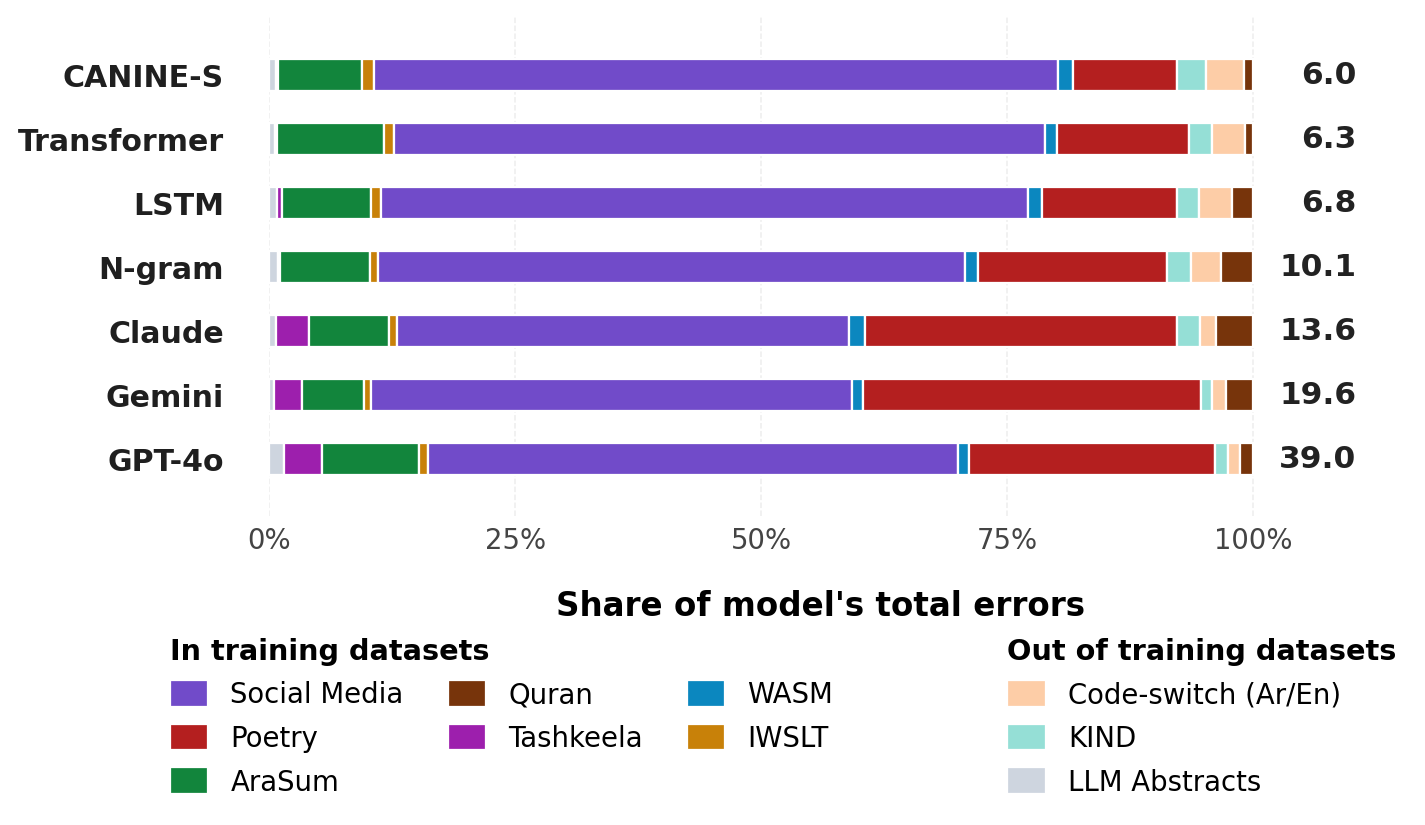

Saved: /raid_storage/SLURM/home/slurm_majedalshaibani/Projects/tnqeet/tnqeet/notebooks/figures/dotting_models_domain_errors_bar.pdf


In [15]:
from io import BytesIO
from IPython.display import Image, display
from matplotlib.patches import Patch

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'Arial'],
    'font.size': 12,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'legend.title_fontsize': 11.5,
    'axes.labelweight': 'bold',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# Refined palette: hues spread across the colour wheel; OOD anchors are
# warm-neutral so their lightened version reads as a quiet off-white.
DOMAIN_COLORS = [
    '#94A3B8',  # LLM Abstracts (OOD)   — cool slate (→ pale blue-gray)
    '#C026D3',  # Tashkeela             — fuchsia (clearly distinct from Poetry's crimson)
    '#16A34A',  # AraSum                — grass green
    '#F59E0B',  # IWSLT                 — amber
    '#8B5CF6',  # Social Media          — violet
    '#0EA5E9',  # WASM                  — sky blue
    '#DC2626',  # Poetry                — crimson
    '#14B8A6',  # KIND                  — teal
    '#FB923C',  # Code-switch (OOD)     — warm orange (→ pale peach)
    '#92400E',  # Quran                 — sepia brown
]
color_for = dict(zip(DOMAINS_ORDER, DOMAIN_COLORS))

def _blend(hex_color, target_rgb, amount):
    r, g, b = (int(hex_color[i:i + 2], 16) for i in (1, 3, 5))
    tr, tg, tb = target_rgb
    return '#{:02X}{:02X}{:02X}'.format(
        int(r + (tr - r) * amount),
        int(g + (tg - g) * amount),
        int(b + (tb - b) * amount),
    )

IN_DARKEN   = 0.18
OOD_LIGHTEN = 0.55

shade_for = {
    d: (_blend(color_for[d], (255, 255, 255), OOD_LIGHTEN) if d in OUT_OF_DOMAIN
        else _blend(color_for[d], (0, 0, 0), IN_DARKEN))
    for d in DOMAINS_ORDER
}

models_sorted = sorted(MODELS, key=lambda m: attribution[m]['overall_pct'])
y_base = np.arange(len(models_sorted))

fig, ax = plt.subplots(figsize=(7.9, 3.6))
fig.patch.set_facecolor('white')

# Stacked horizontal bars.
left = np.zeros(len(models_sorted))
for domain in DOMAINS_ORDER:
    values = np.array([attribution[m]['share'].get(domain, 0.0) for m in models_sorted])
    ax.barh(
        y_base,
        values,
        left=left,
        height=0.50,
        color=shade_for[domain],
        edgecolor='white',
        linewidth=0.9,
    )
    left += values

# Numeric WER values to the right of each bar.
WER_RIGHT_X = 110.5
for i, m in enumerate(models_sorted):
    ax.text(
        WER_RIGHT_X, y_base[i],
        f"{attribution[m]['overall_pct']:.1f}",
        ha='right', va='center',
        fontsize=12.5, fontweight='bold',
        color='#222222',
    )

ax.set_xlim(0, 112)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'], color='#444444')
ax.set_yticks(y_base)
ax.set_yticklabels(models_sorted)
ax.invert_yaxis()
ax.set_xlabel("Share of model's total errors", labelpad=14)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis='x', length=0, pad=4)
ax.tick_params(axis='y', length=0, pad=18)
for label in ax.get_yticklabels():
    label.set_color('#1F1F1F')
    label.set_fontweight(550)
    label.set_fontsize(12)
ax.grid(True, axis='x', alpha=0.22, linestyle='--', linewidth=0.6)
ax.set_axisbelow(True)
ax.margins(y=0.10)

# --- Two legend groups, side by side ----------------------------------------
mean_share = {
    d: float(np.mean([attribution[m]['share'].get(d, 0.0) for m in MODELS]))
    for d in DOMAINS_ORDER
}
in_domain  = sorted([d for d in DOMAINS_ORDER if d not in OUT_OF_DOMAIN], key=lambda d: -mean_share[d])
ood_domain = sorted([d for d in DOMAINS_ORDER if d in OUT_OF_DOMAIN],     key=lambda d: -mean_share[d])

def _patch(d):
    return Patch(
        facecolor=shade_for[d],
        edgecolor='white',
        linewidth=0.9,
        label=DOMAIN_LABELS.get(d, d),
    )

LEGEND_Y = -0.22

# In-training legend is shifted slightly left (axes-x < 0) so it aligns with
# the model-name column rather than the bar area, opening up a clear margin
# between this group and the out-of-training group on the right.
leg_in = ax.legend(
    handles=[_patch(d) for d in in_domain],
    title='In training datasets',
    loc='upper left', bbox_to_anchor=(-0.10, LEGEND_Y),
    ncol=3,
    frameon=False,
    handlelength=1.4, handleheight=1.1,
    columnspacing=1.6,
    labelspacing=0.55,
    borderaxespad=0.0,
)
leg_in.get_title().set_fontweight('bold')
leg_in._legend_box.align = 'left'
ax.add_artist(leg_in)

leg_ood = ax.legend(
    handles=[_patch(d) for d in ood_domain],
    title='Out of training datasets',
    loc='upper left', bbox_to_anchor=(0.66, LEGEND_Y),
    ncol=1,
    frameon=False,
    handlelength=1.4, handleheight=1.1,
    labelspacing=0.55,
    borderaxespad=0.0,
)
leg_ood.get_title().set_fontweight('bold')
leg_ood._legend_box.align = 'left'

# --- Save PDF, then display the *same* tight-bbox render inline -------------
extras = (leg_in, leg_ood)

fig.savefig(
    OUTPUT_PDF, format='pdf',
    bbox_inches='tight', bbox_extra_artists=extras, pad_inches=0.10,
)

buf = BytesIO()
fig.savefig(
    buf, format='png', dpi=180,
    bbox_inches='tight', bbox_extra_artists=extras, pad_inches=0.10,
)
plt.close(fig)
display(Image(buf.getvalue()))
print(f'Saved: {OUTPUT_PDF}')